In [1]:
print("Applied Photonics")

Applied Photonics


In [2]:
c = 3e8          # speed of light in m/s
lambda_nm = 1550 # wavelength in nm (telecom C-band)
lambda_m = lambda_nm * 1e-9  # convert to meters
print(lambda_m)

1.5500000000000002e-06


In [3]:
c = 3e8          # speed of light in m/s

In [4]:
lambda_nm = 1550 # wavelength in nm (telecom C-band)

In [5]:
lambda_m = lambda_nm * 1e-9  # convert to meters

In [6]:
print(lambda_m)

1.5500000000000002e-06


In [7]:
f = c / lambda_m

In [8]:
print(f"Frequency: {f:.4e} Hz")

Frequency: 1.9355e+14 Hz


In [9]:
import math

In [10]:
n1 = 1.46   # core refractive index
n2 = 1.45   # cladding refractive index
NA = math.sqrt(n1**2 - n2**2)
print(f"Numerical aperture: {NA:.4f}")

Numerical aperture: 0.1706


In [11]:
theta_accept = math.degrees(math.asin(NA))
print(f"Acceptance angle: {theta_accept:.2f} degrees")

Acceptance angle: 9.82 degrees


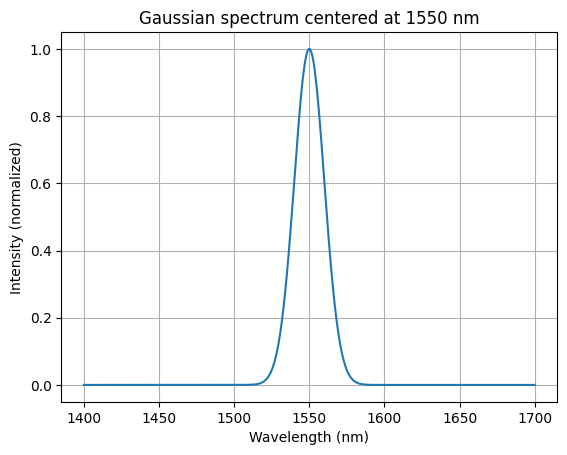

In [12]:
import numpy as np
import matplotlib.pyplot as plt

lambda_range = np.linspace(1400, 1700, 1000)  # like linspace in MATLAB
lambda_0 = 1550
sigma = 10

I = np.exp(-(lambda_range - lambda_0)**2 / (2 * sigma**2))

plt.plot(lambda_range, I)
plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (normalized)')
plt.title('Gaussian spectrum centered at 1550 nm')
plt.grid(True)
plt.show()

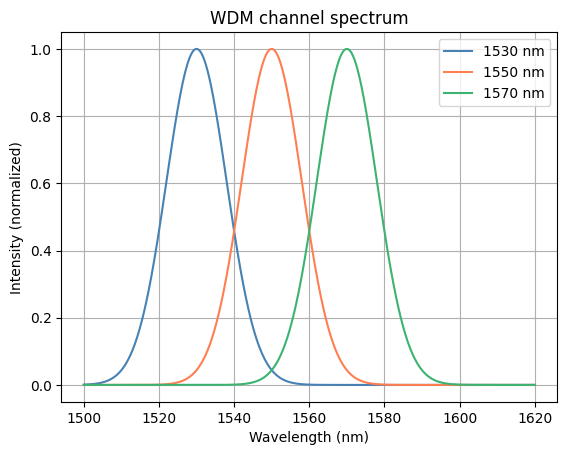

In [13]:
lambda_range = np.linspace(1500, 1620, 1000)
channels = [1530, 1550, 1570]  # three WDM channels
colors = ['steelblue', 'coral', 'mediumseagreen']

for lam, col in zip(channels, colors):
    I = np.exp(-(lambda_range - lam)**2 / (2 * 8**2))
    plt.plot(lambda_range, I, color=col, label=f'{lam} nm')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Intensity (normalized)')
plt.title('WDM channel spectrum')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
for lam in [1530, 1550, 1570]:
    print(f"Channel: {lam} nm")   # inside loop — indented
    
print("Done")                      # outside loop — not indented

Channel: 1530 nm
Channel: 1550 nm
Channel: 1570 nm
Done


In [15]:
2 * 8**2

128

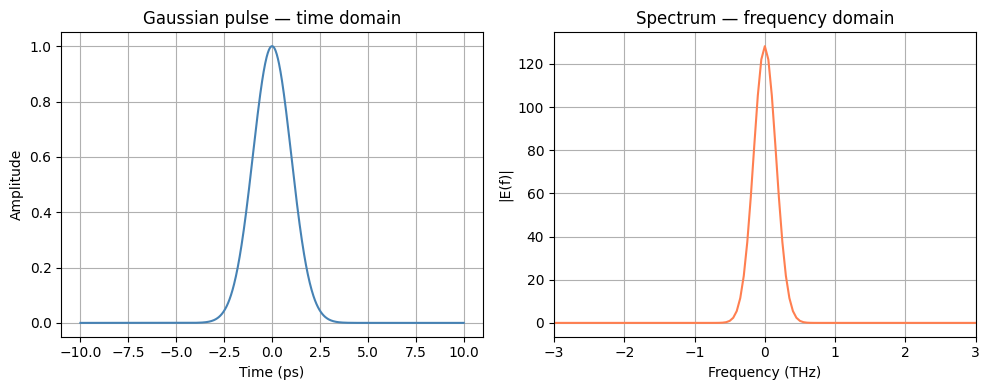

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# A Gaussian pulse in time domain
t = np.linspace(-10, 10, 1024)   # time axis in ps
t0 = 0                            # center
tau = 1                           # pulse width

E = np.exp(-t**2 / (2 * tau**2)) # Gaussian pulse

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(t, E, color='steelblue')
plt.xlabel('Time (ps)')
plt.ylabel('Amplitude')
plt.title('Gaussian pulse — time domain')
plt.grid(True)

# Now compute its Fourier transform
E_fft = np.fft.fftshift(np.fft.fft(E))
freq = np.fft.fftshift(np.fft.fftfreq(len(t), t[1]-t[0]))

plt.subplot(1, 2, 2)
plt.plot(freq, np.abs(E_fft), color='coral')
plt.xlabel('Frequency (THz)')
plt.ylabel('|E(f)|')
plt.title('Spectrum — frequency domain')
plt.xlim(-3, 3)
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
def fresnel_r(n1, n2, theta_deg):
    theta = np.radians(theta_deg)
    cos_i = np.cos(theta)
    cos_t = np.sqrt(1 - (n1/n2 * np.sin(theta))**2)
    r = (n1*cos_i - n2*cos_t) / (n1*cos_i + n2*cos_t)
    return r

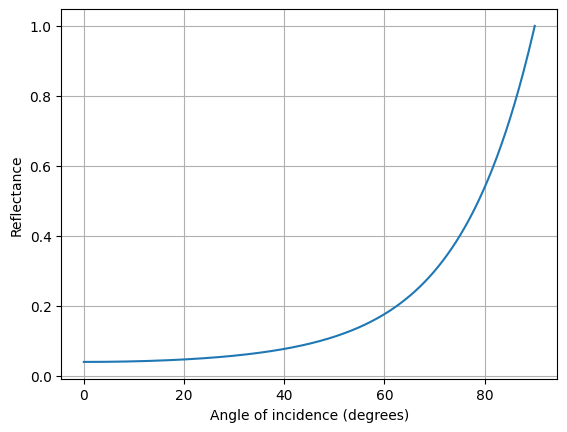

In [18]:
angles = np.linspace(0, 90, 500)
r = fresnel_r(1.0, 1.5, angles)
plt.plot(angles, r**2)
plt.xlabel('Angle of incidence (degrees)')
plt.ylabel('Reflectance')
plt.grid(True)
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt

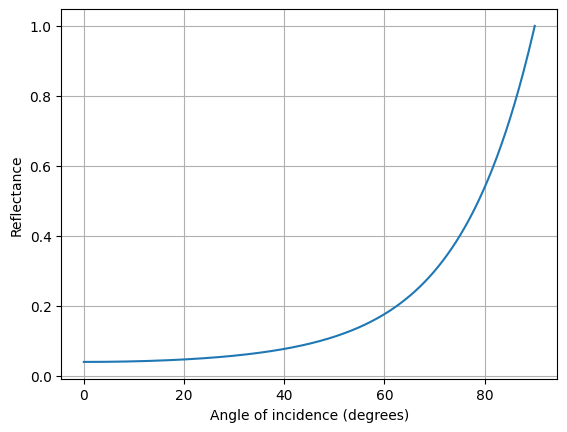

In [20]:
angles = np.linspace(0, 90, 500)
r = fresnel_r(1.0, 1.5, angles)
plt.plot(angles, r**2)
plt.xlabel('Angle of incidence (degrees)')
plt.ylabel('Reflectance')
plt.grid(True)
plt.show()

In [21]:
def fabry_perot_T(lambda_nm, R, n, d):
    lambda_m = lambda_nm * 1e-9
    delta = (4 * np.pi * n * d) / lambda_m
    F = (4 * R) / (1 - R)**2
    T = 1 / (1 + F * np.sin(delta/2)**2)
    return T

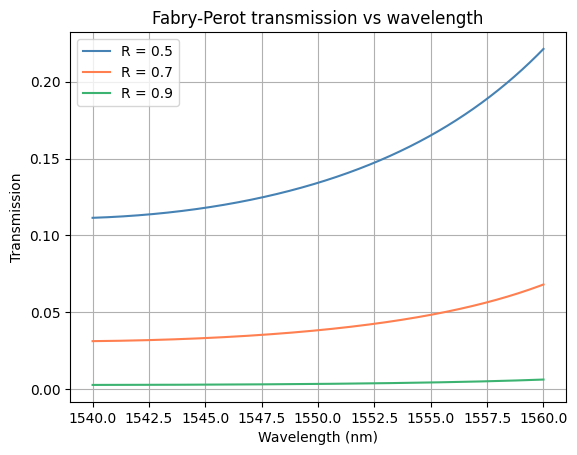

In [22]:
lambda_range = np.linspace(1540, 1560, 10000)
n = 1.5          # refractive index
d = 10e-6        # cavity length 10 microns

for R, col in zip([0.5, 0.7, 0.9], ['steelblue', 'coral', 'mediumseagreen']):
    T = fabry_perot_T(lambda_range, R, n, d)
    plt.plot(lambda_range, T, color=col, label=f'R = {R}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot transmission vs wavelength')
plt.legend()
plt.grid(True)
plt.show()

In [23]:
import numpy as np

def check_TIR(n1, n2, theta_deg):
    # Critical angle
    theta_c = np.degrees(np.arcsin(n2 / n1))
    
    if theta_deg >= theta_c:
        print(f"Total internal reflection occurs — angle {theta_deg}° exceeds critical angle {theta_c:.2f}°")
    else:
        print(f"Light refracts — angle {theta_deg}° is below critical angle {theta_c:.2f}°")

# Test it
check_TIR(n1=1.46, n2=1.45, theta_deg=83)
check_TIR(n1=1.46, n2=1.45, theta_deg=70)

Light refracts — angle 83° is below critical angle 83.29°
Light refracts — angle 70° is below critical angle 83.29°


In [24]:
check_TIR(n1=1.46, n2=1.45, theta_deg=87)

Total internal reflection occurs — angle 87° exceeds critical angle 83.29°


In [25]:
def fiber_mode_classifier(a_um, lambda_nm, n1, n2):
    # Compute NA and V-number
    NA = np.sqrt(n1**2 - n2**2)
    a_m = a_um * 1e-6
    lambda_m = lambda_nm * 1e-9
    V = (2 * np.pi * a_m / lambda_m) * NA
    
    if V < 2.405:
        mode = "single-mode"
    elif V < 10:
        mode = "few-mode"
    else:
        mode = "multimode"
    
    print(f"NA = {NA:.4f}")
    print(f"V-number = {V:.3f}")
    print(f"Fiber is: {mode}")

# Standard single-mode fiber (SMF-28)
print("--- SMF-28 ---")
fiber_mode_classifier(a_um=4.5, lambda_nm=1550, n1=1.4682, n2=1.4629)

# Large core multimode fiber
print("\n--- Multimode fiber ---")
fiber_mode_classifier(a_um=25, lambda_nm=1550, n1=1.46, n2=1.45)

--- SMF-28 ---
NA = 0.1246
V-number = 2.274
Fiber is: single-mode

--- Multimode fiber ---
NA = 0.1706
V-number = 17.288
Fiber is: multimode


In [26]:
print("--- SMF-28 at 1310 nm ---")
fiber_mode_classifier(a_um=4.5, lambda_nm=1310, n1=1.4682, n2=1.4629)

--- SMF-28 at 1310 nm ---
NA = 0.1246
V-number = 2.690
Fiber is: few-mode


In [27]:
def fiber_mode_classifier(a_um, lambda_nm, n1, n2):
    NA = np.sqrt(n1**2 - n2**2)
    a_m = a_um * 1e-6
    lambda_m = lambda_nm * 1e-9
    V = (2 * np.pi * a_m / lambda_m) * NA
    
    if V < 2.405:
        mode = "single-mode"
    elif V < 3.832:
        mode = "few-mode (LP11 guided — practically single-mode over long lengths)"
    elif V < 10:
        mode = "multimode (several modes)"
    else:
        mode = "highly multimode"
    
    print(f"NA = {NA:.4f}")
    print(f"V-number = {V:.3f}")
    print(f"Fiber is: {mode}")

print("--- SMF-28 at 1310 nm ---")
fiber_mode_classifier(a_um=4.5, lambda_nm=1310, n1=1.4682, n2=1.4629)

print("\n--- SMF-28 at 1550 nm ---")
fiber_mode_classifier(a_um=4.5, lambda_nm=1550, n1=1.4682, n2=1.4629)

print("\n--- SMF-28 at 800 nm ---")
fiber_mode_classifier(a_um=4.5, lambda_nm=800, n1=1.4682, n2=1.4629)

--- SMF-28 at 1310 nm ---
NA = 0.1246
V-number = 2.690
Fiber is: few-mode (LP11 guided — practically single-mode over long lengths)

--- SMF-28 at 1550 nm ---
NA = 0.1246
V-number = 2.274
Fiber is: single-mode

--- SMF-28 at 800 nm ---
NA = 0.1246
V-number = 4.405
Fiber is: multimode (several modes)


In [28]:
import numpy as np

def free_space(L):
    """Ray transfer matrix for free space propagation distance L"""
    return np.array([[1, L],
                     [0, 1]])

def thin_lens(f):
    """Ray transfer matrix for a thin lens of focal length f"""
    return np.array([[1,    0],
                     [-1/f, 1]])

# Test: print each matrix
L = 0.1   # 10 cm propagation
f = 0.05  # 5 cm focal length

M_space = free_space(L)
M_lens  = thin_lens(f)

print("Free space matrix:")
print(M_space)
print("\nThin lens matrix:")
print(M_lens)

Free space matrix:
[[1.  0.1]
 [0.  1. ]]

Thin lens matrix:
[[  1.   0.]
 [-20.   1.]]


In [29]:
# A complete system: space → lens → space
# This is the classic single lens imaging system from Chapter 2

L1 = 0.1    # 10 cm before lens
L2 = 0.1    # 10 cm after lens
f  = 0.05   # 5 cm focal length

# System matrix — multiply right to left, just like in your book
M_system = free_space(L2) @ thin_lens(f) @ free_space(L1)

print("System matrix:")
print(M_system)
print(f"\nA = {M_system[0,0]:.4f}")
print(f"B = {M_system[0,1]:.4f}")
print(f"C = {M_system[1,0]:.4f}")
print(f"D = {M_system[1,1]:.4f}")

# Imaging condition: B = 0
if abs(M_system[0,1]) < 1e-10:
    print("\nImaging condition satisfied — this is a perfect imaging system")

System matrix:
[[ -1.   0.]
 [-20.  -1.]]

A = -1.0000
B = 0.0000
C = -20.0000
D = -1.0000

Imaging condition satisfied — this is a perfect imaging system


In [30]:
def resonator_stability(R1, R2, L):
    """
    Check stability of a two-mirror resonator
    R1, R2 : mirror radii of curvature (meters)
    L      : cavity length (meters)
    """
    # Build round trip matrix: space → mirror → space → mirror
    M_mirror1 = thin_lens(R1/2)
    M_mirror2 = thin_lens(R2/2)
    M_L       = free_space(L)
    
    # Full round trip
    M_rt = M_mirror1 @ M_L @ M_mirror2 @ M_L
    
    # Stability parameter
    m = (M_rt[0,0] + M_rt[1,1]) / 2   # half the trace
    
    print(f"Round trip matrix:")
    print(M_rt)
    print(f"\nStability parameter m = {m:.4f}")
    
    if abs(m) <= 1:
        print("Resonator is STABLE")
    else:
        print("Resonator is UNSTABLE")
    
    return M_rt, m

# Test 1 — symmetric concentric resonator
print("--- Symmetric resonator ---")
resonator_stability(R1=0.2, R2=0.2, L=0.1)

--- Symmetric resonator ---
Round trip matrix:
[[-5.55111512e-17  1.00000000e-01]
 [-1.00000000e+01 -1.00000000e+00]]

Stability parameter m = -0.5000
Resonator is STABLE


(array([[-5.55111512e-17,  1.00000000e-01],
        [-1.00000000e+01, -1.00000000e+00]]),
 np.float64(-0.5))

In [31]:
# Test 2 — unstable resonator
print("\n--- Unstable resonator ---")
resonator_stability(R1=0.05, R2=0.05, L=0.5)


--- Unstable resonator ---
Round trip matrix:
[[-19.  -9.]
 [720. 341.]]

Stability parameter m = 161.0000
Resonator is UNSTABLE


(array([[-19.,  -9.],
        [720., 341.]]),
 np.float64(161.0))

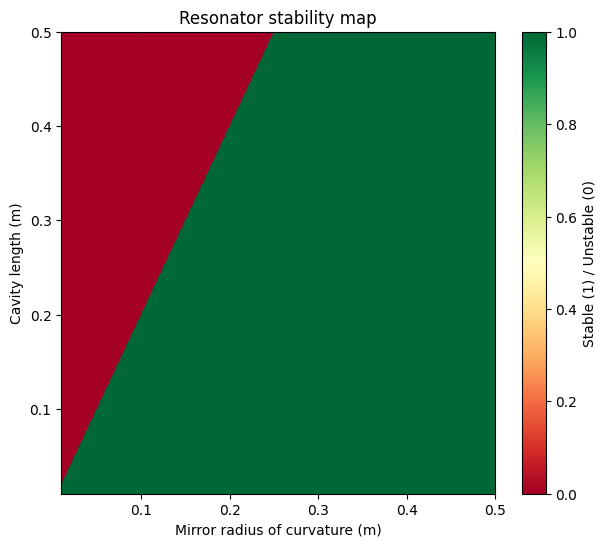

In [32]:
# Scan over cavity length and mirror radius
# and map out stable vs unstable regions

R_values = np.linspace(0.01, 0.5, 300)   # mirror radii
L_values = np.linspace(0.01, 0.5, 300)   # cavity lengths

stability_map = np.zeros((len(L_values), len(R_values)))

for i, L in enumerate(L_values):
    for j, R in enumerate(R_values):
        M_mirror = thin_lens(R/2)
        M_L      = free_space(L)
        M_rt     = M_mirror @ M_L @ M_mirror @ M_L
        m        = (M_rt[0,0] + M_rt[1,1]) / 2
        
        if abs(m) <= 1:
            stability_map[i, j] = 1   # stable
        else:
            stability_map[i, j] = 0   # unstable

plt.figure(figsize=(7, 6))
plt.imshow(stability_map, 
           extent=[R_values[0], R_values[-1], 
                   L_values[0], L_values[-1]],
           origin='lower', 
           cmap='RdYlGn',
           aspect='auto')

plt.colorbar(label='Stable (1) / Unstable (0)')
plt.xlabel('Mirror radius of curvature (m)')
plt.ylabel('Cavity length (m)')
plt.title('Resonator stability map')
plt.show()

In [33]:
import numpy as np

# Recreate the Fabry-Perot data
def fabry_perot_T(lambda_nm, R, n, d):
    lambda_m = lambda_nm * 1e-9
    delta = (4 * np.pi * n * d) / lambda_m
    F = (4 * R) / (1 - R)**2
    T = 1 / (1 + F * np.sin(delta/2)**2)
    return T

lambda_range = np.linspace(1540, 1560, 1000)
T_data = fabry_perot_T(lambda_range, R=0.9, n=1.5, d=10e-6)

# Save to CSV — two columns: wavelength and transmission
data = np.column_stack([lambda_range, T_data])
np.savetxt('fabry_perot_data.csv', data, 
           delimiter=',', 
           header='wavelength_nm, transmission',
           comments='')

print("Data saved to fabry_perot_data.csv")
print(f"Shape of data: {data.shape}")

Data saved to fabry_perot_data.csv
Shape of data: (1000, 2)


Loaded data shape: (1000, 2)
Wavelength range: 1540.00 to 1560.00 nm


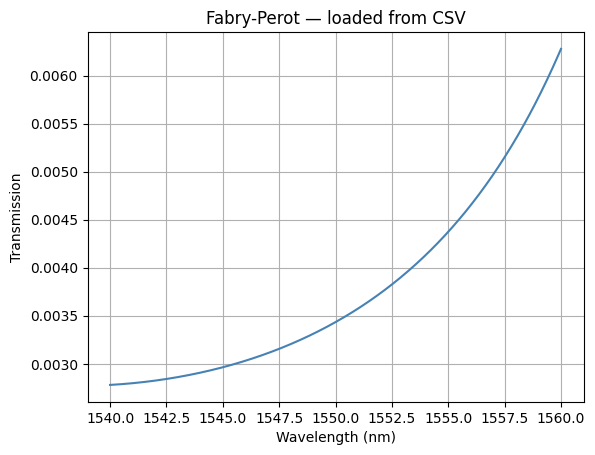

In [34]:
# Load the CSV file back
data_loaded = np.loadtxt('fabry_perot_data.csv', 
                          delimiter=',', 
                          skiprows=1)   # skip the header row

# Split back into two columns
lambda_loaded = data_loaded[:, 0]   # all rows, column 0
T_loaded      = data_loaded[:, 1]   # all rows, column 1

print(f"Loaded data shape: {data_loaded.shape}")
print(f"Wavelength range: {lambda_loaded[0]:.2f} to {lambda_loaded[-1]:.2f} nm")

# Replot to verify
import matplotlib.pyplot as plt

plt.plot(lambda_loaded, T_loaded, color='steelblue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot — loaded from CSV')
plt.grid(True)
plt.show()

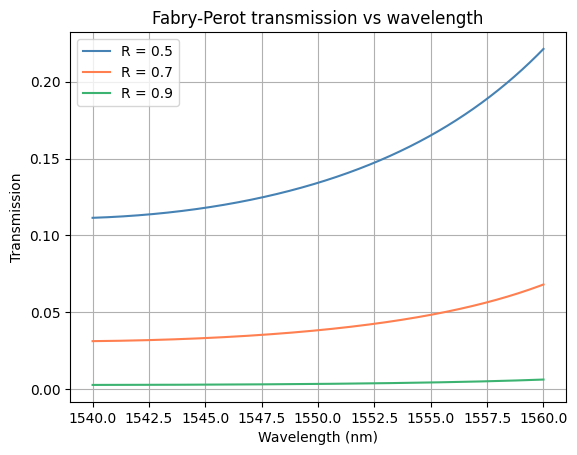

In [35]:
lambda_range = np.linspace(1540, 1560, 10000)
n = 1.5          # refractive index
d = 10e-6        # cavity length 10 microns

for R, col in zip([0.5, 0.7, 0.9], ['steelblue', 'coral', 'mediumseagreen']):
    T = fabry_perot_T(lambda_range, R, n, d)
    plt.plot(lambda_range, T, color=col, label=f'R = {R}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot transmission vs wavelength')
plt.legend()
plt.grid(True)
plt.show()

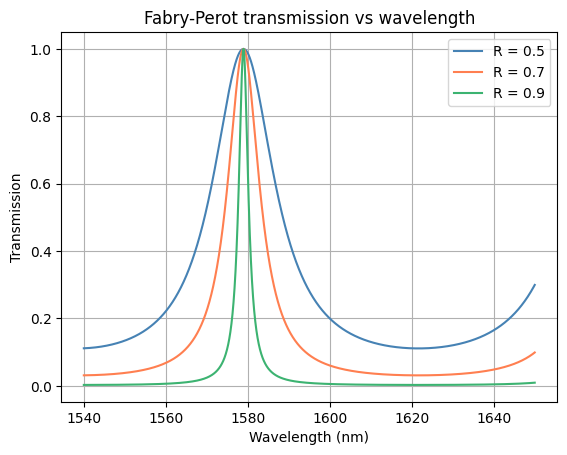

In [36]:
lambda_range = np.linspace(1540, 1650, 10000)
n = 1.5          # refractive index
d = 10e-6        # cavity length 10 microns

for R, col in zip([0.5, 0.7, 0.9], ['steelblue', 'coral', 'mediumseagreen']):
    T = fabry_perot_T(lambda_range, R, n, d)
    plt.plot(lambda_range, T, color=col, label=f'R = {R}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot transmission vs wavelength')
plt.legend()
plt.grid(True)
plt.show()

Loaded data shape: (1000, 2)
Wavelength range: 1540.00 to 1560.00 nm


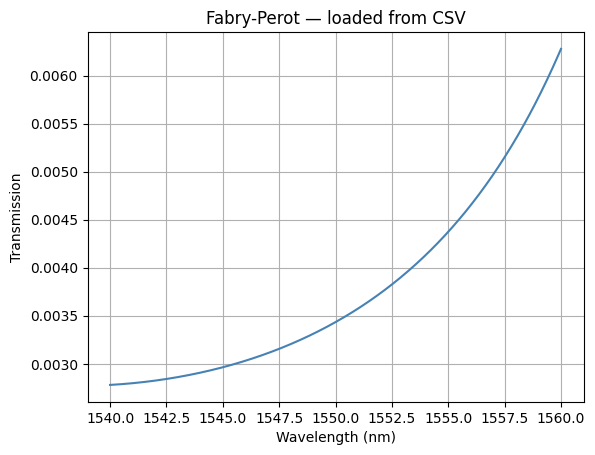

In [37]:
# Load the CSV file back
data_loaded = np.loadtxt('fabry_perot_data.csv', 
                          delimiter=',', 
                          skiprows=1)   # skip the header row

# Split back into two columns
lambda_loaded = data_loaded[:, 0]   # all rows, column 0
T_loaded      = data_loaded[:, 1]   # all rows, column 1

print(f"Loaded data shape: {data_loaded.shape}")
print(f"Wavelength range: {lambda_loaded[0]:.2f} to {lambda_loaded[-1]:.2f} nm")

# Replot to verify
import matplotlib.pyplot as plt

plt.plot(lambda_loaded, T_loaded, color='steelblue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot — loaded from CSV')
plt.grid(True)
plt.show()

In [38]:
import numpy as np

# Recreate the Fabry-Perot data
def fabry_perot_T(lambda_nm, R, n, d):
    lambda_m = lambda_nm * 1e-9
    delta = (4 * np.pi * n * d) / lambda_m
    F = (4 * R) / (1 - R)**2
    T = 1 / (1 + F * np.sin(delta/2)**2)
    return T

lambda_range = np.linspace(1540, 1560, 1000)
T_data = fabry_perot_T(lambda_range, R=0.9, n=1.5, d=10e-6)

# Save to CSV — two columns: wavelength and transmission
data = np.column_stack([lambda_range, T_data])
np.savetxt('fabry_perot_data.csv', data, 
           delimiter=',', 
           header='wavelength_nm, transmission',
           comments='')

print("Data saved to fabry_perot_data.csv")
print(f"Shape of data: {data.shape}")

Data saved to fabry_perot_data.csv
Shape of data: (1000, 2)


Loaded data shape: (1000, 2)
Wavelength range: 1540.00 to 1560.00 nm


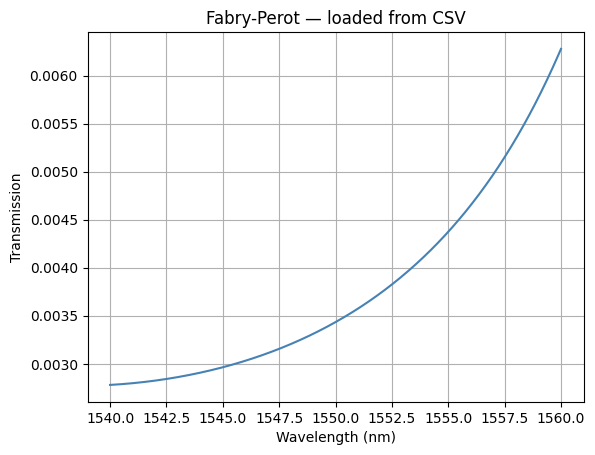

In [39]:
# Load the CSV file back
data_loaded = np.loadtxt('fabry_perot_data.csv', 
                          delimiter=',', 
                          skiprows=1)   # skip the header row

# Split back into two columns
lambda_loaded = data_loaded[:, 0]   # all rows, column 0
T_loaded      = data_loaded[:, 1]   # all rows, column 1

print(f"Loaded data shape: {data_loaded.shape}")
print(f"Wavelength range: {lambda_loaded[0]:.2f} to {lambda_loaded[-1]:.2f} nm")

# Replot to verify
import matplotlib.pyplot as plt

plt.plot(lambda_loaded, T_loaded, color='steelblue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot — loaded from CSV')
plt.grid(True)
plt.show()

In [40]:
import numpy as np

# Recreate the Fabry-Perot data
def fabry_perot_T(lambda_nm, R, n, d):
    lambda_m = lambda_nm * 1e-9
    delta = (4 * np.pi * n * d) / lambda_m
    F = (4 * R) / (1 - R)**2
    T = 1 / (1 + F * np.sin(delta/2)**2)
    return T

lambda_range = np.linspace(1540, 1640, 1000)
T_data = fabry_perot_T(lambda_range, R=0.9, n=1.5, d=10e-6)

# Save to CSV — two columns: wavelength and transmission
data = np.column_stack([lambda_range, T_data])
np.savetxt('fabry_perot_data.csv', data, 
           delimiter=',', 
           header='wavelength_nm, transmission',
           comments='')

print("Data saved to fabry_perot_data.csv")
print(f"Shape of data: {data.shape}")

Data saved to fabry_perot_data.csv
Shape of data: (1000, 2)


Loaded data shape: (1000, 2)
Wavelength range: 1540.00 to 1640.00 nm


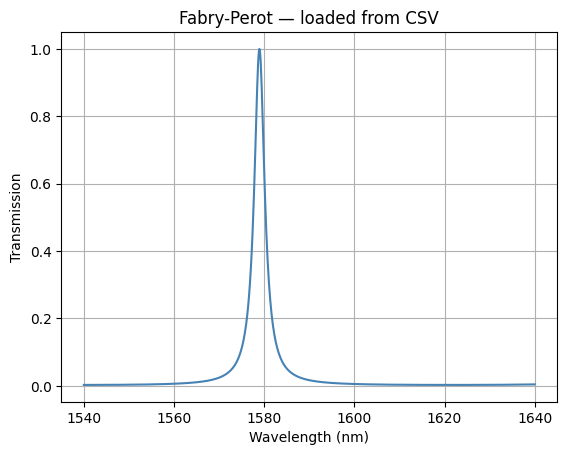

In [41]:
# Load the CSV file back
data_loaded = np.loadtxt('fabry_perot_data.csv', 
                          delimiter=',', 
                          skiprows=1)   # skip the header row

# Split back into two columns
lambda_loaded = data_loaded[:, 0]   # all rows, column 0
T_loaded      = data_loaded[:, 1]   # all rows, column 1

print(f"Loaded data shape: {data_loaded.shape}")
print(f"Wavelength range: {lambda_loaded[0]:.2f} to {lambda_loaded[-1]:.2f} nm")

# Replot to verify
import matplotlib.pyplot as plt

plt.plot(lambda_loaded, T_loaded, color='steelblue')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot — loaded from CSV')
plt.grid(True)
plt.show()

In [42]:
import pandas as pd

# Load the CSV directly into a pandas DataFrame
df = pd.read_csv('fabry_perot_data.csv')

# Inspect it
print(df.head(10))        # first 10 rows — like head() in R or first 10 rows in MATLAB
print(f"\nShape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

   wavelength_nm   transmission
0    1540.000000       0.002780
1    1540.100100       0.002782
2    1540.200200       0.002783
3    1540.300300       0.002785
4    1540.400400       0.002787
5    1540.500501       0.002788
6    1540.600601       0.002790
7    1540.700701       0.002792
8    1540.800801       0.002794
9    1540.900901       0.002796

Shape: (1000, 2)

Column names: ['wavelength_nm', ' transmission']


In [43]:
import pandas as pd

# Load the CSV directly into a pandas DataFrame
df = pd.read_csv('fabry_perot_data.csv')

# Inspect it
print(df.head(10))        # first 10 rows — like head() in R or first 10 rows in MATLAB
print(f"\nShape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

   wavelength_nm   transmission
0    1540.000000       0.002780
1    1540.100100       0.002782
2    1540.200200       0.002783
3    1540.300300       0.002785
4    1540.400400       0.002787
5    1540.500501       0.002788
6    1540.600601       0.002790
7    1540.700701       0.002792
8    1540.800801       0.002794
9    1540.900901       0.002796

Shape: (1000, 2)

Column names: ['wavelength_nm', ' transmission']


In [44]:
import pandas as pd

# Load the CSV directly into a pandas DataFrame
df = pd.read_csv('fabry_perot_data.csv')

# Inspect it
print(df.head(10))        # first 10 rows — like head() in R or first 10 rows in MATLAB
print(f"\nShape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

   wavelength_nm   transmission
0    1540.000000       0.002780
1    1540.100100       0.002782
2    1540.200200       0.002783
3    1540.300300       0.002785
4    1540.400400       0.002787
5    1540.500501       0.002788
6    1540.600601       0.002790
7    1540.700701       0.002792
8    1540.800801       0.002794
9    1540.900901       0.002796

Shape: (1000, 2)

Column names: ['wavelength_nm', ' transmission']


In [45]:
import subprocess
subprocess.run(['pip', 'install', 'pandas'])

CompletedProcess(args=['pip', 'install', 'pandas'], returncode=0)

In [46]:
import pandas as pd
print(pd.__version__)

3.0.1


In [47]:
import pandas as pd

# Load the CSV directly into a pandas DataFrame
df = pd.read_csv('fabry_perot_data.csv')

# Inspect it
print(df.head(10))        # first 10 rows — like head() in R or first 10 rows in MATLAB
print(f"\nShape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}"

_IncompleteInputError: incomplete input (3198270903.py, line 9)

In [ ]:
print(f"\nColumn names: {df.columns.tolist()}"

In [ ]:
import pandas as pd

# Load the CSV directly into a pandas DataFrame
df = pd.read_csv('fabry_perot_data.csv')

# Inspect it
print(df.head(10))        # first 10 rows — like head() in R or first 10 rows in MATLAB
print(f"\nShape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")

In [ ]:
# Basic statistics — one line
print("Basic statistics:")
print(df.describe())

# Filter — find only rows where transmission > 0.5
high_T = df[df['transmission'] > 0.5]
print(f"\nNumber of points with T > 0.5: {len(high_T)}")
print(high_T.head())

# Find the wavelength of peak transmission
peak_idx = df['transmission'].idxmax()
peak_lambda = df['wavelength_nm'][peak_idx]
print(f"\nPeak transmission at: {peak_lambda:.4f} nm")

In [ ]:
print(df.columns.tolist())
print(df.head(3))

In [ ]:
# Strip any hidden spaces from column names
df.columns = df.columns.str.strip()

# Verify
print(df.columns.tolist())

# Now try again
print(df.head(10))
print(f"\nShape: {df.shape}")

In [ ]:
# Basic statistics
print("Basic statistics:")
print(df.describe())

# Filter — transmission > 0.5
high_T = df[df['transmission'] > 0.5]
print(f"\nNumber of points with T > 0.5: {len(high_T)}")
print(high_T.head())

# Peak transmission wavelength
peak_idx = df['transmission'].idxmax()
peak_lambda = df['wavelength_nm'][peak_idx]
print(f"\nPeak transmission at: {peak_lambda:.4f} nm")

In [ ]:
df[df['transmission'] > 0.5]

In [ ]:
photonics_tools.py

In [ ]:
import numpy as np

def fresnel_r(n1, n2, theta_deg):
    """Fresnel reflection coefficient for s-polarization"""
    theta = np.radians(theta_deg)
    cos_i = np.cos(theta)
    cos_t = np.sqrt(1 - (n1/n2 * np.sin(theta))**2)
    r = (n1*cos_i - n2*cos_t) / (n1*cos_i + n2*cos_t)
    return r

def fabry_perot_T(lambda_nm, R, n, d):
    """Fabry-Perot transmission function"""
    lambda_m = lambda_nm * 1e-9
    delta = (4 * np.pi * n * d) / lambda_m
    F = (4 * R) / (1 - R)**2
    T = 1 / (1 + F * np.sin(delta/2)**2)
    return T

def fiber_NA(n1, n2):
    """Numerical aperture of a step-index fiber"""
    return np.sqrt(n1**2 - n2**2)

def fiber_V(a_um, lambda_nm, n1, n2):
    """V-number of a step-index fiber"""
    NA = fiber_NA(n1, n2)
    return (2 * np.pi * a_um*1e-6 / (lambda_nm*1e-9)) * NA

def fiber_mode_classifier(a_um, lambda_nm, n1, n2):
    """Classify fiber as single-mode, few-mode, or multimode"""
    V = fiber_V(a_um, lambda_nm, n1, n2)
    NA = fiber_NA(n1, n2)
    if V < 2.405:
        mode = "single-mode"
    elif V < 3.832:
        mode = "few-mode"
    else:
        mode = "multimode"
    print(f"NA = {NA:.4f}")
    print(f"V-number = {V:.3f}")
    print(f"Fiber is: {mode}")
    return V

def free_space(L):
    """Ray transfer matrix for free space propagation"""
    return np.array([[1, L],
                     [0, 1]])

def thin_lens(f):
    """Ray transfer matrix for a thin lens"""
    return np.array([[1,    0],
                     [-1/f, 1]])

def resonator_stability(R1, R2, L):
    """Check stability of a two-mirror resonator"""
    M_rt = thin_lens(R1/2) @ free_space(L) @ thin_lens(R2/2) @ free_space(L)
    m = (M_rt[0,0] + M_rt[1,1]) / 2
    stable = abs(m) <= 1
    print(f"Stability parameter m = {m:.4f}")
    print(f"Resonator is {'STABLE' if stable else 'UNSTABLE'}")
    return M_rt, m

In [ ]:
import photonics_tools as pt

# Now call any function with the pt. prefix
NA = pt.fiber_NA(n1=1.46, n2=1.45)
print(f"NA = {NA:.4f}")

V = pt.fiber_V(a_um=4.5, lambda_nm=1550, n1=1.4682, n2=1.4629)
print(f"V-number = {V:.3f}")

In [ ]:
import photonics_tools as pt

# Now call any function with the pt. prefix
NA = pt.fiber_NA(n1=1.46, n2=1.45)
print(f"NA = {NA:.4f}")

V = pt.fiber_V(a_um=4.5, lambda_nm=1550, n1=1.4682, n2=1.4629)
print(f"V-number = {V:.3f}")

In [ ]:
help(pt.fabry_perot_T)

In [ ]:
fiber = {
    "name":       "SMF-28",
    "core_um":    4.5,
    "lambda_nm":  1550,
    "n1":         1.4682,
    "n2":         1.4629
}

In [ ]:
fiber["core_um"]    # returns 4.5
fiber["name"]       # returns "SMF-28"

In [ ]:
fiber["core_um"]    # returns 4.5    # returns "SMF-28"

In [ ]:
# Define a fiber as a dictionary
smf28 = {
    "name":      "SMF-28",
    "core_um":   4.5,
    "lambda_nm": 1550,
    "n1":        1.4682,
    "n2":        1.4629
}

# Access individual values
print(f"Fiber: {smf28['name']}")
print(f"Core diameter: {smf28['core_um']} um")

# Pass dictionary values directly into your function
import photonics_tools as pt

V = pt.fiber_V(
    a_um       = smf28["core_um"],
    lambda_nm  = smf28["lambda_nm"],
    n1         = smf28["n1"],
    n2         = smf28["n2"]
)
print(f"V-number: {V:.3f}")

In [ ]:
# A catalog of fibers
fiber_catalog = [
    {"name": "SMF-28",     "core_um": 4.5,  "lambda_nm": 1550, "n1": 1.4682, "n2": 1.4629},
    {"name": "MM-50um",    "core_um": 25.0, "lambda_nm": 1550, "n1": 1.46,   "n2": 1.45},
    {"name": "DCF",        "core_um": 2.5,  "lambda_nm": 1550, "n1": 1.47,   "n2": 1.46},
]

print(f"{'Fiber':<12} {'V-number':>10} {'Mode':<15}")
print("-" * 38)

for fiber in fiber_catalog:
    V  = pt.fiber_V(fiber["core_um"], fiber["lambda_nm"], fiber["n1"], fiber["n2"])
    NA = pt.fiber_NA(fiber["n1"], fiber["n2"])
    
    if V < 2.405:
        mode = "single-mode"
    elif V < 3.832:
        mode = "few-mode"
    else:
        mode = "multimode"
    
    print(f"{fiber['name']:<12} {V:>10.3f} {mode:<15}")

In [ ]:
# This is what an AI API response looks like
api_response = {
    "id":      "msg_01XFDUDYJgAACzvnptvVoYEL",
    "model":   "claude-sonnet-4-6",
    "content": [
        {
            "type": "text",
            "text": "The V-number of SMF-28 at 1550nm is 2.274..."
        }
    ],
    "usage": {
        "input_tokens":  25,
        "output_tokens": 110
    }
}

# You extract the answer exactly like any dictionary
answer = api_response["content"][0]["text"]
tokens_used = api_response["usage"]["output_tokens"]

print(f"AI answer: {answer}")
print(f"Tokens used: {tokens_used

In [ ]:
# This is what an AI API response looks like
api_response = {
    "id":      "msg_01XFDUDYJgAACzvnptvVoYEL",
    "model":   "claude-sonnet-4-6",
    "content": [
        {
            "type": "text",
            "text": "The V-number of SMF-28 at 1550nm is 2.274..."
        }
    ],
    "usage": {
        "input_tokens":  25,
        "output_tokens": 110
    }
}

# You extract the answer exactly like any dictionary
answer = api_response["content"][0]["text"]
tokens_used = api_response["usage"]["output_tokens"]

print(f"AI answer: {answer}")
print(f"Tokens used: {tokens_used

In [ ]:
# This is what an AI API response looks like
api_response = {
    "id":      "msg_01XFDUDYJgAACzvnptvVoYEL",
    "model":   "claude-sonnet-4-6",
    "content": [
        {
            "type": "text",
            "text": "The V-number of SMF-28 at 1550nm is 2.274..."
        }
    ],
    "usage": {
        "input_tokens":  25,
        "output_tokens": 110
    }
}

# You extract the answer exactly like any dictionary
answer = api_response["content"][0]["text"]
tokens_used = api_response["usage"]["output_tokens"]

print(f"AI answer: {answer}")
print(f"Tokens used: {tokens_used}

In [ ]:
# This is what an AI API response looks like
api_response = {
    "id":      "msg_01XFDUDYJgAACzvnptvVoYEL",
    "model":   "claude-sonnet-4-6",
    "content": [
        {
            "type": "text",
            "text": "The V-number of SMF-28 at 1550nm is 2.274..."
        }
    ],
    "usage": {
        "input_tokens":  25,
        "output_tokens": 110
    }
}

# You extract the answer exactly like any dictionary
answer = api_response["content"][0]["text"]
tokens_used = api_response["usage"]["output_tokens"]

print(f"AI answer: {answer}")
print(f"Tokens used: {tokens_used}")

# Applied Photonics — Python Toolkit
## Mustafa A. G. Abushagur
### Rochester Institute of Technology

This notebook implements key computational tools from *Applied Photonics* (Springer, 2025).
Each section corresponds to a chapter in the book.

**Contents:**
- Chapter 2: Ray transfer matrices (ABCD)
- Chapter 3: Fresnel reflection coefficients
- Chapter 6: Fabry-Perot resonator transmission
- Chapter 7: Fiber V-number and mode classification
- Chapter 8: Fiber numerical aperture

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import photonics_tools as pt

## Chapter 2 — Ray Transfer Matrices (ABCD)

The ABCD matrix method describes paraxial ray propagation through optical systems.
Each optical element is represented by a 2×2 matrix. The system matrix is the 
product of individual element matrices, applied right to left.

$$M_{system} = M_n \cdot ... \cdot M_2 \cdot M_1$$

In [ ]:
# Single lens imaging system
L1 = 0.1    # object distance (m)
L2 = 0.1    # image distance (m)
f  = 0.05   # focal length (m)

M_system = pt.free_space(L2) @ pt.thin_lens(f) @ pt.free_space(L1)

print("System ABCD matrix:")
print(M_system)
print(f"\nImaging condition B = {M_system[0,1]:.6f} (should be 0)")

## Chapter 3 — Fresnel Reflection Coefficients

The Fresnel equations describe reflection and transmission at a dielectric interface.
Reflectance R = r² where r is the amplitude reflection coefficient.
The Brewster angle occurs where R = 0 for p-polarization.

In [ ]:
angles = np.linspace(0, 90, 500)
r = pt.fresnel_r(1.0, 1.5, angles)

plt.figure(figsize=(7, 4))
plt.plot(angles, r**2, color='steelblue')
plt.xlabel('Angle of incidence (degrees)')
plt.ylabel('Reflectance')
plt.title('Fresnel reflectance — air to glass (n=1.5)')
plt.grid(True)
plt.show()

## Chapter 6 — Fabry-Perot Resonator

The Fabry-Perot transmission function describes the wavelength-selective 
transmission of a two-mirror cavity:

$$T = \frac{1}{1 + F\sin^2(\delta/2)}$$

where $F = \frac{4R}{(1-R)^2}$ is the finesse coefficient and 
$\delta = \frac{4\pi n d}{\lambda}$ is the round-trip phase.
Higher mirror reflectivity R produces sharper, narrower transmission peaks.

In [ ]:
lambda_range = np.linspace(1540, 1640, 10000)
n = 1.5
d = 10e-6

plt.figure(figsize=(8, 4))
for R, col in zip([0.5, 0.7, 0.9], ['steelblue', 'coral', 'mediumseagreen']):
    T = pt.fabry_perot_T(lambda_range, R, n, d)
    plt.plot(lambda_range, T, color=col, label=f'R = {R}')

plt.xlabel('Wavelength (nm)')
plt.ylabel('Transmission')
plt.title('Fabry-Perot transmission vs wavelength')
plt.legend()
plt.grid(True)
plt.show()

## Chapter 7 & 8 — Optical Fiber Parameters

The V-number determines the number of modes a fiber supports:

$$V = \frac{2\pi a}{\lambda} \cdot NA, \quad NA = \sqrt{n_1^2 - n_2^2}$$

- $V < 2.405$ → single-mode
- $2.405 < V < 3.832$ → few-mode  
- $V > 3.832$ → multimode

In [ ]:
fiber_catalog = [
    {"name": "SMF-28",  "core_um": 4.5,  "lambda_nm": 1550, "n1": 1.4682, "n2": 1.4629},
    {"name": "MM-50um", "core_um": 25.0, "lambda_nm": 1550, "n1": 1.46,   "n2": 1.45},
    {"name": "DCF",     "core_um": 2.5,  "lambda_nm": 1550, "n1": 1.47,   "n2": 1.46},
]

print(f"{'Fiber':<12} {'NA':>8} {'V-number':>10} {'Mode':<15}")
print("-" * 48)

for fiber in fiber_catalog:
    NA = pt.fiber_NA(fiber["n1"], fiber["n2"])
    V  = pt.fiber_V(fiber["core_um"], fiber["lambda_nm"], fiber["n1"], fiber["n2"])
    
    if V < 2.405:
        mode = "single-mode"
    elif V < 3.832:
        mode = "few-mode"
    else:
        mode = "multimode"
    
    print(f"{fiber['name']:<12} {NA:>8.4f} {V:>10.3f} {mode:<15}")

In [ ]:
## Summary

This toolkit implements the core computational methods from *Applied Photonics*.
All functions are available in `photonics_tools.py` for use in any notebook.

**Built with:** Python 3 · NumPy · matplotlib · pandas  
**Reference:** Abushagur, M.A.G., *Applied Photonics*, Springer, 2025.

## Summary

This toolkit implements the core computational methods from *Applied Photonics*.
All functions are available in `photonics_tools.py` for use in any notebook.

**Built with:** Python 3 · NumPy · matplotlib · pandas  
**Reference:** Abushagur, M.A.G., *Applied Photonics*, Springer, 2025.